# Chapter 93 - Final Project: Tiny Style Imitation

Chapter 92 showed that a small corpus shapes what a tiny GPT can predict and generate.

This project holds architecture, initialization, tokenizer, optimization, and sampling settings constant while changing the training corpus from paragraph prose to short poetry-like lines.

## Learning goals

By the end of this chapter, you will be able to:

- prepare two contrasting text corpora with complete-unit holdouts;
- compare corpus character, punctuation, vocabulary, and line-break patterns;
- train identically initialized TinyGPT models with matched settings;
- compare generated samples and aggregate surface metrics;
- measure exact overlap with unrepeated training text; and
- explain why surface imitation, memorization, and literary understanding are different claims.

## Define the experiment

**Style** here means measurable surface patterns such as character choice, punctuation, line length, line breaks, and recurring word forms.

**Style imitation** means generated samples reproduce some of those distributions.

**Memorization** means a model reproduces exact training spans.

Neither behavior demonstrates that the model understands an author, literary intent, rhythm, or meaning.

The corpus should be the only intended experimental variable, although stochastic training and a tiny sample still limit causal conclusions.

## Describe the self-contained fixtures accurately

The prose fixture combines an excerpt from Lewis Carroll's *Alice's Adventures in Wonderland* with course-created narrative paragraphs supplied for this project.

The Carroll work was published in 1865 and is public domain in the United States, while the poetry-like fixture is course-created rather than an attributed historical poem.

A serious author-comparison project should use verified editions of two documented public-domain sources and record their provenance.

## Define prose paragraphs

Each prose unit is normalized onto one line so blank lines carry paragraph structure rather than source-code wrapping.

In [1]:
prose_units_raw = [
    """Alice was beginning to get very tired of sitting by her sister on the bank,
    and of having nothing to do. Once or twice she had peeped into the book her
    sister was reading, but it had no pictures or conversations in it, and what is
    the use of a book, thought Alice, without pictures or conversation?""",
    """So she was considering in her own mind, as well as she could, for the hot day
    made her feel very sleepy and stupid, whether the pleasure of making a daisy
    chain would be worth the trouble of getting up and picking the daisies, when
    suddenly a white rabbit with pink eyes ran close by her.""",
    """There was nothing so very remarkable in that; nor did Alice think it so very
    much out of the way to hear the rabbit say to itself, Oh dear! Oh dear! I shall
    be too late! But when the rabbit actually took a watch out of its waistcoat
    pocket, and looked at it, and then hurried on, Alice started to her feet.""",
    """The rabbit-hole went straight on like a tunnel for some way, and then dipped
    suddenly down, so suddenly that Alice had not a moment to think about stopping
    herself before she found herself falling down what seemed to be a very deep
    well.""",
    """In the morning, the village road was quiet. The baker lifted the shutters, the
    cart rolled over the stones, and smoke rose from the chimneys. Everyone seemed
    to be waiting for something, though no one could say what it was.""",
    """The old clock in the hall had stopped at half past three. Clara stood before it
    with a candle in her hand and listened. Somewhere behind the wall there was a
    soft tapping, like a branch touching glass, but there were no trees near that
    side of the house.""",
]


def normalize_prose_unit(unit: str) -> str:
    return " ".join(unit.split()).lower()


prose_units = [normalize_prose_unit(unit) for unit in prose_units_raw]

## Define poetry-like stanzas

These course-created stanzas deliberately use four short lines, rhyme-like endings, and frequent line breaks.

They are a controlled contrast fixture, not evidence about any named poet's style.

In [2]:
poetry_units_raw = [
    """A narrow wind went through the grass,
    and bent the quiet flowers low;
    the morning held a silver glass,
    where hidden waters seemed to glow.""",
    """The little bird upon the wall
    looked once upon the empty lane;
    then lifted, at a distant call,
    and left the garden still again.""",
    """Because the night was deep and wide,
    the candle made a golden room;
    and every shadow seemed to hide
    a folded leaf, a breath, a bloom.""",
    """I heard a footstep in the rain,
    then nothing but the rain was there;
    the window darkened at the pane,
    the lamp burned softly in the air.""",
    """The moon was not a thing of stone,
    but something listening in the sky;
    the road went wandering alone,
    and no one asked the reason why.""",
    """A letter slept beneath the door,
    its little seal of faded red;
    I read the first line o'er and o'er,
    then laid it by the silent bed.""",
]


def normalize_poetry_unit(unit: str) -> str:
    return "\n".join(" ".join(line.split()).lower() for line in unit.splitlines())


poetry_units = [normalize_poetry_unit(unit) for unit in poetry_units_raw]

## Split complete units before repetition

Each corpus reserves two complete units with the same deterministic split procedure.

Only the four training units are repeated, which prevents exact held-out passages from appearing in training copies.

In [3]:
import random  # noqa: I001


def split_units(units: list[str], seed: int) -> tuple[list[str], list[str]]:
    indexes = list(range(len(units)))
    generator = random.Random(seed)
    generator.shuffle(indexes)
    validation_indexes = set(indexes[:2])
    training_units = [
        unit for index, unit in enumerate(units) if index not in validation_indexes
    ]
    validation_units = [
        unit for index, unit in enumerate(units) if index in validation_indexes
    ]
    return training_units, validation_units


prose_training_units, prose_validation_units = split_units(prose_units, seed=93)
poetry_training_units, poetry_validation_units = split_units(poetry_units, seed=93)
prose_training_source = "\n\n".join(prose_training_units)
poetry_training_source = "\n\n".join(poetry_training_units)
prose_validation_text = "\n\n".join(prose_validation_units)
poetry_validation_text = "\n\n".join(poetry_validation_units)
prose_training_text = (prose_training_source + "\n\n") * 12
poetry_training_text = (poetry_training_source + "\n\n") * 12

print("training units per corpus:", len(prose_training_units))
print("held-out units per corpus:", len(prose_validation_units))
print("prose training characters:", len(prose_training_text))
print("poetry training characters:", len(poetry_training_text))

training units per corpus: 4
held-out units per corpus: 2
prose training characters: 12864
poetry training characters: 6588


The corpora differ in length as well as formatting, but both models receive the same number of parameter updates and batches of the same shape.

Consequently, this experiment compares equal compute rather than equal passes through each character.

## Measure source surface patterns

Character frequencies are proportions, so repeating a corpus does not change them.

We calculate them from the unrepeated training sources and plot characters with the largest absolute differences.

In [4]:
from collections import Counter  # noqa: I001


def character_frequencies(text: str) -> dict[str, float]:
    counts = Counter(text)
    return {character: count / len(text) for character, count in counts.items()}


prose_frequencies = character_frequencies(prose_training_source)
poetry_frequencies = character_frequencies(poetry_training_source)
comparison_characters = sorted(
    set(prose_frequencies) | set(poetry_frequencies),
    key=lambda character: abs(
        prose_frequencies.get(character, 0.0) - poetry_frequencies.get(character, 0.0)
    ),
    reverse=True,
)[:18]
print("characters with largest frequency differences:")
for character in comparison_characters[:8]:
    difference = prose_frequencies.get(character, 0.0) - poetry_frequencies.get(
        character, 0.0
    )
    print(repr(character), f"prose minus poetry = {difference:+.4f}")

characters with largest frequency differences:
'\n' prose minus poetry = -0.0273
' ' prose minus poetry = +0.0242
'n' prose minus poetry = -0.0199
't' prose minus poetry = +0.0175
'e' prose minus poetry = -0.0170
'd' prose minus poetry = -0.0157
'o' prose minus poetry = +0.0153
'w' prose minus poetry = -0.0142


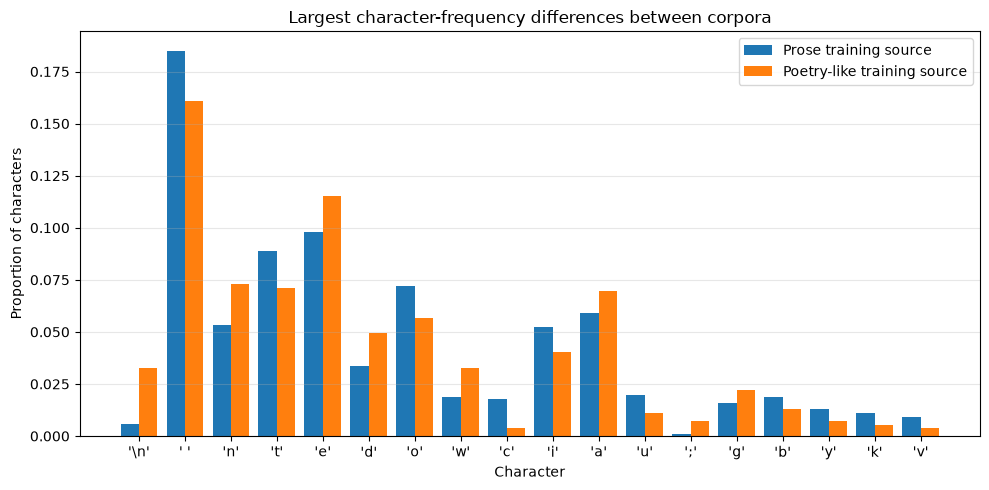

In [5]:
import matplotlib.pyplot as plt  # noqa: I001


positions = list(range(len(comparison_characters)))
bar_width = 0.4
plt.figure(figsize=(10, 5))
plt.bar(
    [position - bar_width / 2 for position in positions],
    [prose_frequencies.get(character, 0.0) for character in comparison_characters],
    width=bar_width,
    label="Prose training source",
)
plt.bar(
    [position + bar_width / 2 for position in positions],
    [poetry_frequencies.get(character, 0.0) for character in comparison_characters],
    width=bar_width,
    label="Poetry-like training source",
)
plt.xticks(positions, [repr(character) for character in comparison_characters])
plt.xlabel("Character")
plt.ylabel("Proportion of characters")
plt.title("Largest character-frequency differences between corpora")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

The newline token is a structural signal: poetry uses it between every line, while prose uses it only between paragraphs.

Letter-frequency differences also reflect the particular vocabulary of these tiny fixtures rather than a universal distinction between prose and poetry.

## Compare line, punctuation, and vocabulary statistics

The next table adds surface measurements that a character-frequency plot cannot summarize alone.

In [6]:
from dataclasses import dataclass  # noqa: I001
import re  # noqa: I001


@dataclass(frozen=True)
class SurfaceMetrics:
    newline_rate: float
    punctuation_rate: float
    average_line_length: float
    unique_word_types: int


def surface_metrics(text: str) -> SurfaceMetrics:
    nonempty_lines = [line for line in text.splitlines() if line]
    punctuation = set(",.!?;:'-")
    words = re.findall(r"[a-z]+", text)
    return SurfaceMetrics(
        newline_rate=100 * text.count("\n") / len(text),
        punctuation_rate=100
        * sum(character in punctuation for character in text)
        / len(text),
        average_line_length=sum(map(len, nonempty_lines)) / len(nonempty_lines),
        unique_word_types=len(set(words)),
    )


def print_surface_metrics(label: str, metrics: SurfaceMetrics) -> None:
    print(
        f"{label:<20} {metrics.newline_rate:>10.2f} "
        f"{metrics.punctuation_rate:>12.2f} "
        f"{metrics.average_line_length:>12.2f} "
        f"{metrics.unique_word_types:>12}"
    )


print(
    f"{'source':<20} {'newlines':>10} {'punctuation':>12} "
    f"{'line length':>12} {'word types':>12}"
)
print("-" * 70)
print_surface_metrics("Prose source", surface_metrics(prose_training_source))
print_surface_metrics("Poetry source", surface_metrics(poetry_training_source))

source                 newlines  punctuation  line length   word types
----------------------------------------------------------------------
Prose source               0.56         2.52       266.00          117
Poetry source              3.29         3.11        33.06           71


Rates are reported per 100 characters, average line length excludes blank separator lines, and word types are lowercase letter sequences.

These operational definitions make the comparison reproducible but do not capture rhythm, syntax, or meaning.

## Use one fixed tokenizer

Both models share a predefined lowercase character inventory, so token IDs and vocabulary size cannot explain later differences.

In [7]:
characters = sorted(set("\n abcdefghijklmnopqrstuvwxyz,.!?;:'-"))
character_to_id = {character: token_id for token_id, character in enumerate(characters)}
id_to_character = {
    token_id: character for character, token_id in character_to_id.items()
}


def encode_text(text: str) -> list[int]:
    unknown_characters = sorted(set(text) - set(character_to_id))
    if unknown_characters:
        raise ValueError(f"Unknown characters: {unknown_characters}")
    return [character_to_id[character] for character in text]


def decode_token_ids(token_ids: list[int]) -> str:
    return "".join(id_to_character[token_id] for token_id in token_ids)


for corpus_text in [
    prose_training_text,
    prose_validation_text,
    poetry_training_text,
    poetry_validation_text,
]:
    assert decode_token_ids(encode_text(corpus_text)) == corpus_text
print("shared vocabulary size:", len(characters))

shared vocabulary size: 36


## Build reproducible next-character batches

Each target sequence is its input sequence shifted one character to the left.

In [8]:
import torch  # noqa: I001


prose_training_ids = torch.tensor(encode_text(prose_training_text), dtype=torch.long)
prose_validation_ids = torch.tensor(
    encode_text(prose_validation_text), dtype=torch.long
)
poetry_training_ids = torch.tensor(encode_text(poetry_training_text), dtype=torch.long)
poetry_validation_ids = torch.tensor(
    encode_text(poetry_validation_text), dtype=torch.long
)


def get_training_batch(
    token_ids: torch.Tensor,
    batch_size: int,
    context_length: int,
    generator: torch.Generator,
) -> tuple[torch.Tensor, torch.Tensor]:
    if token_ids.ndim != 1:
        raise ValueError("token_ids must be one-dimensional.")
    number_of_starts = token_ids.shape[0] - context_length
    if number_of_starts < 1:
        raise ValueError("The token stream is too short for this context length.")
    starts = torch.randint(0, number_of_starts, (batch_size,), generator=generator)
    inputs = torch.stack(
        [token_ids[start : start + context_length] for start in starts]
    )
    targets = torch.stack(
        [token_ids[start + 1 : start + context_length + 1] for start in starts]
    )
    return inputs, targets


test_generator = torch.Generator().manual_seed(93)
test_inputs, test_targets = get_training_batch(
    prose_training_ids, batch_size=4, context_length=16, generator=test_generator
)
print("input shape:", tuple(test_inputs.shape))
print("target shift is correct:", torch.equal(test_inputs[:, 1:], test_targets[:, :-1]))

input shape: (4, 16)
target shift is correct: True


## Define the shared TinyGPT architecture

The same vectorized causal-attention classes are used for both training runs.

In [9]:
import math  # noqa: I001
import torch


class MultiHeadCausalSelfAttention(torch.nn.Module):
    embedding_dimension: int
    number_of_attention_heads: int
    head_size: int

    def __init__(
        self,
        embedding_dimension: int,
        number_of_attention_heads: int,
        context_length: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        if embedding_dimension % number_of_attention_heads != 0:
            raise ValueError("Attention heads must divide the embedding dimension.")
        self.embedding_dimension = embedding_dimension
        self.number_of_attention_heads = number_of_attention_heads
        self.head_size = embedding_dimension // number_of_attention_heads
        self.query_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension, bias=False
        )
        self.key_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension, bias=False
        )
        self.value_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension, bias=False
        )
        self.output_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension
        )
        self.attention_dropout = torch.nn.Dropout(dropout_rate)
        self.output_dropout = torch.nn.Dropout(dropout_rate)
        self.register_buffer(
            "causal_mask",
            torch.tril(torch.ones(context_length, context_length, dtype=torch.bool)),
        )

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        batch_size, sequence_length, _ = input_values.shape

        def split_heads(values: torch.Tensor) -> torch.Tensor:
            return values.view(
                batch_size,
                sequence_length,
                self.number_of_attention_heads,
                self.head_size,
            ).transpose(1, 2)

        queries = split_heads(self.query_projection(input_values))
        keys = split_heads(self.key_projection(input_values))
        values = split_heads(self.value_projection(input_values))
        attention_scores = queries @ keys.transpose(-2, -1)
        attention_scores = attention_scores / math.sqrt(self.head_size)
        causal_mask = self.causal_mask[:sequence_length, :sequence_length]
        attention_scores = attention_scores.masked_fill(~causal_mask, float("-inf"))
        attention_weights = torch.softmax(attention_scores, dim=-1)
        attended_values = self.attention_dropout(attention_weights) @ values
        concatenated_values = (
            attended_values.transpose(1, 2)
            .contiguous()
            .view(batch_size, sequence_length, self.embedding_dimension)
        )
        projected_values = self.output_projection(concatenated_values)
        output_values: torch.Tensor = self.output_dropout(projected_values)
        return output_values

In [10]:
class FeedForwardNetwork(torch.nn.Module):
    def __init__(self, embedding_dimension: int, dropout_rate: float) -> None:
        super().__init__()
        self.network = torch.nn.Sequential(
            torch.nn.Linear(embedding_dimension, 4 * embedding_dimension),
            torch.nn.ReLU(),
            torch.nn.Linear(4 * embedding_dimension, embedding_dimension),
            torch.nn.Dropout(dropout_rate),
        )

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        output_values: torch.Tensor = self.network(input_values)
        return output_values


class TransformerBlock(torch.nn.Module):
    def __init__(
        self,
        embedding_dimension: int,
        number_of_attention_heads: int,
        context_length: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        self.attention_norm = torch.nn.LayerNorm(embedding_dimension)
        self.attention = MultiHeadCausalSelfAttention(
            embedding_dimension=embedding_dimension,
            number_of_attention_heads=number_of_attention_heads,
            context_length=context_length,
            dropout_rate=dropout_rate,
        )
        self.feedforward_norm = torch.nn.LayerNorm(embedding_dimension)
        self.feedforward = FeedForwardNetwork(
            embedding_dimension=embedding_dimension,
            dropout_rate=dropout_rate,
        )

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        attention_branch = self.attention(self.attention_norm(input_values))
        values_after_attention = input_values + attention_branch
        feedforward_branch = self.feedforward(
            self.feedforward_norm(values_after_attention)
        )
        output_values: torch.Tensor = values_after_attention + feedforward_branch
        return output_values


class TinyGPT(torch.nn.Module):
    vocabulary_size: int
    context_length: int

    def __init__(
        self,
        vocabulary_size: int,
        context_length: int,
        embedding_dimension: int,
        number_of_attention_heads: int,
        number_of_transformer_blocks: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        self.vocabulary_size = vocabulary_size
        self.context_length = context_length
        self.token_embedding = torch.nn.Embedding(vocabulary_size, embedding_dimension)
        self.position_embedding = torch.nn.Embedding(
            context_length, embedding_dimension
        )
        self.embedding_dropout = torch.nn.Dropout(dropout_rate)
        self.transformer_blocks = torch.nn.Sequential(
            *[
                TransformerBlock(
                    embedding_dimension=embedding_dimension,
                    number_of_attention_heads=number_of_attention_heads,
                    context_length=context_length,
                    dropout_rate=dropout_rate,
                )
                for _ in range(number_of_transformer_blocks)
            ]
        )
        self.final_norm = torch.nn.LayerNorm(embedding_dimension)
        self.output_layer = torch.nn.Linear(embedding_dimension, vocabulary_size)

    def forward(
        self,
        input_token_ids: torch.Tensor,
        target_token_ids: torch.Tensor | None = None,
    ) -> tuple[torch.Tensor, torch.Tensor | None]:
        if input_token_ids.ndim != 2:
            raise ValueError("Inputs must have shape [batch, time].")
        batch_size, sequence_length = input_token_ids.shape
        if sequence_length > self.context_length:
            raise ValueError("Input exceeds model context length.")
        position_ids = torch.arange(sequence_length, device=input_token_ids.device)
        hidden_values = self.token_embedding(input_token_ids)
        hidden_values = hidden_values + self.position_embedding(position_ids)
        hidden_values = self.embedding_dropout(hidden_values)
        hidden_values = self.transformer_blocks(hidden_values)
        logits = self.output_layer(self.final_norm(hidden_values))
        loss = None
        if target_token_ids is not None:
            if target_token_ids.shape != input_token_ids.shape:
                raise ValueError("Targets must have the same shape as inputs.")
            loss = torch.nn.functional.cross_entropy(
                logits.reshape(batch_size * sequence_length, self.vocabulary_size),
                target_token_ids.reshape(batch_size * sequence_length),
            )
        return logits, loss

    @torch.no_grad()
    def generate(
        self,
        input_token_ids: torch.Tensor,
        number_of_new_tokens: int,
        generator: torch.Generator,
        temperature: float = 1.0,
        top_k: int | None = None,
    ) -> torch.Tensor:
        if temperature <= 0:
            raise ValueError("temperature must be positive.")
        generated_ids = input_token_ids
        for _ in range(number_of_new_tokens):
            model_input = generated_ids[:, -self.context_length :]
            logits, _ = self(model_input)
            next_logits = logits[:, -1] / temperature
            if top_k is not None:
                effective_top_k = min(top_k, self.vocabulary_size)
                top_values, _ = torch.topk(next_logits, effective_top_k)
                next_logits = next_logits.masked_fill(
                    next_logits < top_values[:, -1, None], float("-inf")
                )
            probabilities = torch.softmax(next_logits, dim=-1)
            next_ids = torch.multinomial(
                probabilities, num_samples=1, generator=generator
            )
            generated_ids = torch.cat([generated_ids, next_ids], dim=1)
        return generated_ids

## Train with matched settings

Resetting the global PyTorch seed recreates identical initial parameters and dropout streams for each model.

Local batch and evaluation generators also start from the same seeds, while different corpus lengths map their sampled indexes to different text positions.

In [11]:
@dataclass
class TrainingResult:
    corpus_name: str
    model: TinyGPT
    initial_parameters: torch.Tensor
    evaluation_steps: list[int]
    training_losses: list[float]
    validation_losses: list[float]


context_length = 48
training_steps = 500
evaluation_interval = 125


@torch.no_grad()
def estimate_loss(
    model: TinyGPT,
    token_ids: torch.Tensor,
    generator: torch.Generator,
) -> float:
    was_training = model.training
    model.eval()
    losses: list[float] = []
    for _ in range(8):
        inputs, targets = get_training_batch(
            token_ids, batch_size=16, context_length=context_length, generator=generator
        )
        _, loss = model(inputs, targets)
        if loss is None:
            raise RuntimeError("Evaluation loss was not computed.")
        losses.append(loss.item())
    model.train(was_training)
    return sum(losses) / len(losses)


def train_style_model(
    corpus_name: str,
    training_ids: torch.Tensor,
    validation_ids: torch.Tensor,
) -> TrainingResult:
    torch.manual_seed(93)
    model = TinyGPT(
        vocabulary_size=len(characters),
        context_length=context_length,
        embedding_dimension=48,
        number_of_attention_heads=4,
        number_of_transformer_blocks=2,
        dropout_rate=0.1,
    )
    initial_parameters = (
        torch.nn.utils.parameters_to_vector(model.parameters()).detach().clone()
    )
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.01)
    batch_generator = torch.Generator().manual_seed(9301)
    training_evaluation_generator = torch.Generator().manual_seed(9302)
    validation_evaluation_generator = torch.Generator().manual_seed(9303)
    evaluation_steps: list[int] = []
    training_losses: list[float] = []
    validation_losses: list[float] = []

    def record_losses(step: int) -> None:
        evaluation_steps.append(step)
        training_losses.append(
            estimate_loss(model, training_ids, training_evaluation_generator)
        )
        validation_losses.append(
            estimate_loss(model, validation_ids, validation_evaluation_generator)
        )
        print(
            f"{corpus_name:<7} | step {step:>3} "
            f"| train {training_losses[-1]:.3f} "
            f"| validation {validation_losses[-1]:.3f}"
        )

    record_losses(0)
    model.train()
    for step in range(1, training_steps + 1):
        inputs, targets = get_training_batch(
            training_ids,
            batch_size=16,
            context_length=context_length,
            generator=batch_generator,
        )
        logits, loss = model(inputs, targets)
        if loss is None or not torch.isfinite(loss):
            raise RuntimeError("Training loss is missing or non-finite.")
        if logits.shape[-1] != len(characters):
            raise RuntimeError("Model output does not match the shared vocabulary.")
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        if step % evaluation_interval == 0:
            record_losses(step)

    return TrainingResult(
        corpus_name,
        model,
        initial_parameters,
        evaluation_steps,
        training_losses,
        validation_losses,
    )

In [12]:
prose_result = train_style_model("prose", prose_training_ids, prose_validation_ids)
poetry_result = train_style_model("poetry", poetry_training_ids, poetry_validation_ids)

assert torch.equal(prose_result.initial_parameters, poetry_result.initial_parameters)
print("identical initial parameters: True")
print("parameters per model:", prose_result.initial_parameters.numel())

prose   | step   0 | train 3.597 | validation 3.639


prose   | step 125 | train 2.476 | validation 2.547


prose   | step 250 | train 2.238 | validation 2.426


prose   | step 375 | train 2.133 | validation 2.401


prose   | step 500 | train 2.052 | validation 2.371
poetry  | step   0 | train 3.667 | validation 3.634


poetry  | step 125 | train 2.273 | validation 2.650


poetry  | step 250 | train 2.002 | validation 2.634


poetry  | step 375 | train 1.809 | validation 2.734


poetry  | step 500 | train 1.664 | validation 2.830
identical initial parameters: True
parameters per model: 62148


Identical initial tensors remove one important source of variation, but a single pair of training runs still cannot estimate seed-to-seed uncertainty.

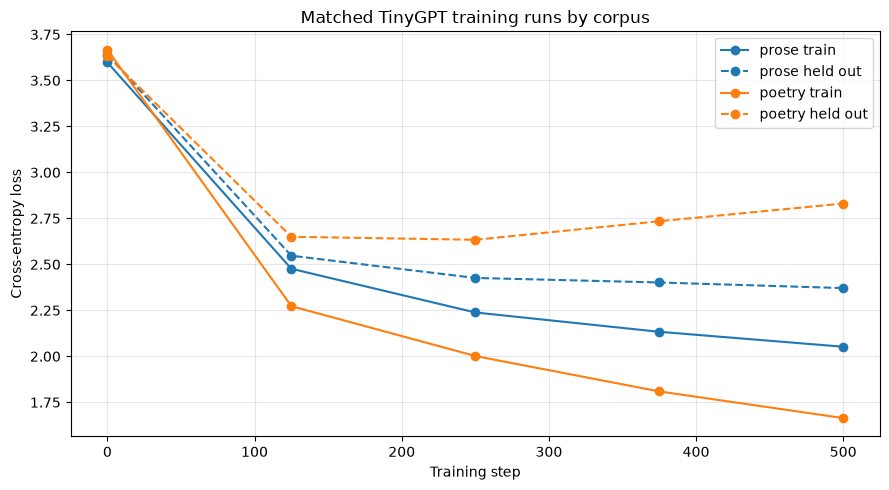

In [13]:
plt.figure(figsize=(9, 5))
for result, color in [(prose_result, "tab:blue"), (poetry_result, "tab:orange")]:
    plt.plot(
        result.evaluation_steps,
        result.training_losses,
        marker="o",
        color=color,
        linestyle="-",
        label=f"{result.corpus_name} train",
    )
    plt.plot(
        result.evaluation_steps,
        result.validation_losses,
        marker="o",
        color=color,
        linestyle="--",
        label=f"{result.corpus_name} held out",
    )
plt.xlabel("Training step")
plt.ylabel("Cross-entropy loss")
plt.title("Matched TinyGPT training runs by corpus")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Loss values are not a direct style score because each corpus has a different predictability and held-out sample.

The curves only show whether each model became better at next-character prediction on its own data.

In this run, poetry held-out loss reaches its minimum early and then rises while training loss keeps falling, which is a concrete sign of overfitting to the repeated stanzas.

Prose held-out loss continues to decline through the final recorded step, although its tiny holdout remains noisy.

## Generate from the same prompt

Both models receive identical sampling settings and an explicit seed.

The helper retains the full prompt while cropping only the conditioning input if it exceeds the model context.

In [14]:
@torch.no_grad()
def generate_text(
    model: TinyGPT,
    prompt: str,
    number_of_new_tokens: int,
    seed: int,
) -> str:
    if not prompt:
        raise ValueError("Prompt must not be empty.")
    prompt_ids = encode_text(prompt)
    model_input = torch.tensor([prompt_ids[-model.context_length :]], dtype=torch.long)
    generator = torch.Generator().manual_seed(seed)
    model.eval()
    generated_ids = model.generate(
        model_input,
        number_of_new_tokens=number_of_new_tokens,
        generator=generator,
        temperature=0.8,
        top_k=15,
    )
    continuation = generated_ids[0, model_input.shape[1] :].tolist()
    return prompt + decode_token_ids([int(token_id) for token_id in continuation])


comparison_prompt = "the"
prose_sample = generate_text(prose_result.model, comparison_prompt, 320, seed=93)
poetry_sample = generate_text(poetry_result.model, comparison_prompt, 320, seed=93)
print("=" * 72)
print("PROSE-TRAINED MODEL")
print(prose_sample)
print("=" * 72)
print("POETRY-TRAINED MODEL")
print(poetry_sample)

PROSE-TRAINED MODEL
the ronnd o wacto anocher wher a walinkit rabenl ict se tome bf ntongino dory fon wary r, thooonveme sar ve inithathe bar lld wh waor ng bersing iked oke te wer! he r! tedethed ly waeered te sere istad fo ome wat bitwalin t ituromut oto here aters s serene atoutuin ar t toar hedery or d bd wat.






tor ad alait the t ab
POETRY-TRAINED MODEL
the mongut rn hig anecas,
anthe,
the rnininas mly;
t an the w fthe anind dory.
the winde,
the we wane asend rarowa d agle lowhero aorend mernd gld wirofow theerid rofld adetheaneanereere, anouree,
athe flooma winded w ld ad a wa bur remed ideatedlow bedeca atourendep wtolourronde,
an rd bum.
the;
t r.
a wad ald rarooflde 


The poetry-trained sample should be inspected for shorter lines and more frequent line breaks, while the prose-trained sample may favor longer uninterrupted spans.

Word fragments and grammatical failures are expected from both tiny models.

## Aggregate several generated samples

One attractive or strange sample can be misleading, so each surface comparison averages eight independently seeded continuations.

In [15]:
def generate_sample_collection(model: TinyGPT) -> list[str]:
    return [
        generate_text(model, comparison_prompt, 180, seed=9300 + sample_index)
        for sample_index in range(8)
    ]


prose_samples = generate_sample_collection(prose_result.model)
poetry_samples = generate_sample_collection(poetry_result.model)


def average_surface_metrics(samples: list[str]) -> SurfaceMetrics:
    metrics = [surface_metrics(sample) for sample in samples]
    return SurfaceMetrics(
        newline_rate=sum(metric.newline_rate for metric in metrics) / len(metrics),
        punctuation_rate=sum(metric.punctuation_rate for metric in metrics)
        / len(metrics),
        average_line_length=sum(metric.average_line_length for metric in metrics)
        / len(metrics),
        unique_word_types=round(
            sum(metric.unique_word_types for metric in metrics) / len(metrics)
        ),
    )


print(
    f"{'text':<20} {'newlines':>10} {'punctuation':>12} "
    f"{'line length':>12} {'word types':>12}"
)
print("-" * 70)
print_surface_metrics("Prose source", surface_metrics(prose_training_source))
print_surface_metrics("Prose generated", average_surface_metrics(prose_samples))
print_surface_metrics("Poetry source", surface_metrics(poetry_training_source))
print_surface_metrics("Poetry generated", average_surface_metrics(poetry_samples))

text                   newlines  punctuation  line length   word types
----------------------------------------------------------------------
Prose source               0.56         2.52       266.00          117
Prose generated            0.20         1.02       171.38           33
Poetry source              3.29         3.11        33.06           71
Poetry generated           2.19         1.91        41.70           28


Generated statistics need not match their sources exactly, but movement in the same direction is evidence that the model learned a surface distinction.

Tiny models can exaggerate frequent structural tokens, so an excessive newline rate is not necessarily better imitation.

## Check exact overlap with training text

The longest-common-substring diagnostic measures the longest contiguous character span each generated continuation shares with its own unrepeated training source.

Removing the common prompt prevents it from inflating the result.

In [16]:
from statistics import median  # noqa: I001


def longest_shared_substring(first_text: str, second_text: str) -> str:
    previous_lengths = [0] * (len(second_text) + 1)
    best_length = 0
    best_end = 0
    for first_index, first_character in enumerate(first_text, start=1):
        current_lengths = [0] * (len(second_text) + 1)
        for second_index, second_character in enumerate(second_text, start=1):
            if first_character == second_character:
                current_lengths[second_index] = previous_lengths[second_index - 1] + 1
                if current_lengths[second_index] > best_length:
                    best_length = current_lengths[second_index]
                    best_end = first_index
        previous_lengths = current_lengths
    return first_text[best_end - best_length : best_end]


def report_copying(label: str, samples: list[str], training_source: str) -> None:
    matches = [
        longest_shared_substring(sample[len(comparison_prompt) :], training_source)
        for sample in samples
    ]
    longest_match = max(matches, key=len)
    print(label)
    print("median longest-match length:", median(map(len, matches)))
    print("maximum longest-match length:", len(longest_match))
    print("maximum match:", repr(longest_match))


report_copying("Prose model", prose_samples, prose_training_source)
print()
report_copying("Poetry model", poetry_samples, poetry_training_source)

Prose model
median longest-match length: 6.0
maximum longest-match length: 8
maximum match: 'alice wa'

Poetry model
median longest-match length: 7.0
maximum longest-match length: 9
maximum match: ' but the '


Long exact matches increase concern about memorization, but short common phrases can occur naturally and exact matching misses near-copies.

Surface metrics should therefore be interpreted together with overlap checks and direct sample review.

## Review the comparison consistently

Ask the same questions of both model collections:

- Do line breaks resemble the corresponding source format?
- Are punctuation and line lengths moving toward the source statistics?
- Are there recurring words or only character fragments?
- Does the model reproduce unusually long training spans?
- Are observed differences stable across several samples?
- Would the claim still hold across several training seeds?

This avoids selecting only the examples that support a preferred conclusion.

## Limits

- One corpus includes historical and course-created prose, while the other is course-created poetry-like text.
- Four repeated training units per corpus create strong memorization pressure.
- Two held-out units produce noisy loss estimates.
- Equal update counts do not mean equal numbers of corpus passes.
- One initialization cannot show seed-to-seed variation.
- Character-level surface statistics do not measure literary quality or meaning.

These restrictions make this a teaching experiment about dataset effects, not an author-style benchmark.

## Takeaways

- Split by complete paragraphs or stanzas before repetition.
- Share tokenizer, architecture, initialization, compute budget, and sampling settings when isolating corpus choice.
- Corpus character frequencies, punctuation, vocabulary, and line breaks provide concrete comparison targets.
- Aggregate multiple generated samples rather than selecting one favorite output.
- Check exact overlap because memorization can resemble successful style imitation.
- Tiny models often learn and exaggerate surface quirks before they learn coherent language.
- Resembling a dataset is not the same as understanding an author or a literary style.

A stronger follow-up would use two verified public-domain collections, multiple documents per split, several training seeds, and exact plus near-duplicate detection.